# 03 Frame Sampling & Swin Transformer / DETR — IPAD 실습


### 본 실습에서 다루는 기술

| 기법 | 한 줄 설명 | 코드에서의 역할 |
|------|-----------|----------------|
| **디코딩 병목 분석** | CPU 순차/랜덤/배치 읽기 성능 비교 | `benchmark_opencv_*` |
| **프레임 샘플링** | Uniform / Consecutive / Strided / Motion / Cycle | `FrameSampler` |
| **배치 로딩** | Decord `get_batch` 패턴 재현 | `IpadBatchReader` |
| **자동 export** | 샘플링 결과를 폴더·manifest JSON 저장 | `export_sampled_clip` |
| **Swin Transformer** | 계층적 Window Attention 2D ViT | HF `microsoft/swin-tiny-patch4-window7-224` |
| **DETR** | Transformer Encoder-Decoder 객체 검출 | HF `facebook/detr-resnet-50` |

교재 핵심 메시지: 디코딩 속도를 개선하면(최대 약 7배 throughput) 실시간 다채널 분석이 가능해집니다.


In [1]:
# !pip install -q -r requirements.txt

#! pip install -U nvidia-ml-py
#! pip install decord>=0.6.0

In [2]:
from __future__ import annotations

import json
import os
import platform
import subprocess
import textwrap
import zipfile
from dataclasses import dataclass, field
from enum import Enum
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from matplotlib.gridspec import GridSpec
from PIL import Image, ImageDraw
from scipy import signal as sp_signal
from transformers import (
    AutoImageProcessor,
    AutoModelForImageClassification,
    DetrForObjectDetection,
    DetrImageProcessor,
)

# ── 경로·모델 설정 ───────────────────────────────────────────────────────────

IPAD_ZIP_NAMES = ("IPAD_sample.zip", "IPAD_Sample.zip")
IPAD_EXTRACT_DIR = Path("IPAD_Sample")
IPAD_SEARCH_PATHS = [IPAD_EXTRACT_DIR, Path("IPAD_sample"), Path("IPAD")]

OUTPUT_DIR = Path("output_sampling")
FIG_DIR = OUTPUT_DIR / "figures"
SAMPLE_DIR = OUTPUT_DIR / "sampled_frames"
MANIFEST_PATH = OUTPUT_DIR / "sampling_manifest.json"

SELECTED_DEVICE: str | None = "R01"
SELECTED_CLIP: str | None = "01"
FPS_ASSUMED = 30.0

SWIN_NUM_FRAMES = 8
DETR_NUM_FRAMES = 6
PREVIEW_NUM_FRAMES = 12

SWIN_MODEL_ID = "microsoft/swin-tiny-patch4-window7-224"
DETR_MODEL_ID = "facebook/detr-resnet-50"
DETR_SCORE_THRESHOLD = 0.35

RUN_SWIN = True
RUN_DETR = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for d in (OUTPUT_DIR, FIG_DIR, SAMPLE_DIR):
    d.mkdir(parents=True, exist_ok=True)


def is_running_in_colab() -> bool:
    """Google Colab 런타임 여부 — 한글 폰트 설치 분기용."""
    try:
        import google.colab  # noqa: F401
        return True
    except ImportError:
        return False


def setup_matplotlib_korean() -> None:
    """
    matplotlib 한글·마이너스 기호 깨짐 방지.
    OS별로 설치된 고딕 계열 폰트를 우선 탐색하고, 없으면 ttf 직접 등록.
    """
    from matplotlib import font_manager
    if is_running_in_colab():
        subprocess.run(
            ["apt-get", "-qq", "-y", "install", "fonts-nanum"],
            check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
        )
        font_manager._load_fontmanager(try_read_cache=False)
    if platform.system() == "Windows":
        candidates = ["Malgun Gothic", "NanumGothic", "Gulim"]
        fallback = Path(os.environ.get("WINDIR", r"C:\Windows")) / "Fonts" / "malgun.ttf"
    elif platform.system() == "Darwin":
        candidates = ["AppleGothic", "Apple SD Gothic Neo"]
        fallback = None
    else:
        candidates = ["NanumGothic", "NanumBarunGothic"]
        fallback = Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
    available = {f.name for f in font_manager.fontManager.ttflist}
    chosen = next((n for n in candidates if n in available), None)
    if chosen:
        plt.rcParams["font.family"] = chosen
    elif fallback and fallback.exists():
        font_manager.fontManager.addfont(str(fallback))
        plt.rcParams["font.family"] = font_manager.FontProperties(fname=str(fallback)).get_name()
    plt.rcParams["axes.unicode_minus"] = False


setup_matplotlib_korean()
print(f"환경 설정 완료 | device={DEVICE}")


환경 설정 완료 | device=cuda


In [3]:
FRAME_EXTS = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}


@dataclass
class IpadClip:
    """IPAD 프레임 시퀀스 클립 (설비 1개 영상 = 프레임 폴더)."""
    device: str
    split: str
    clip_id: str
    frame_dir: Path
    frame_paths: list[Path]

    @property
    def num_frames(self) -> int:
        return len(self.frame_paths)


def _is_valid_ipad_root(base: Path) -> bool:
    """하위에 `{설비}/training/frames/` 가 있으면 유효한 IPAD 루트."""
    if not base.is_dir():
        return False
    for child in base.iterdir():
        if child.is_dir() and (child / "training" / "frames").is_dir():
            return True
    return (base / "training" / "frames").is_dir()


def find_ipad_zip() -> Path | None:
    """현재 작업 디렉터리에서 IPAD_sample.zip 파일을 찾는다."""
    cwd = Path(".")
    for name in IPAD_ZIP_NAMES:
        p = cwd / name
        if p.is_file():
            return p
    for f in cwd.iterdir():
        if f.is_file() and f.suffix.lower() == ".zip" and f.stem.lower() == "ipad_sample":
            return f
    return None


def ensure_ipad_sample() -> Path | None:
    """
    IPAD_sample.zip을 현재 경로에서 찾아, 필요 시 IPAD_Sample/ 로 압축 해제한다.
    이미 풀려 있으면 재추출하지 않는다.
    """
    for base in IPAD_SEARCH_PATHS:
        if _is_valid_ipad_root(base):
            return base

    zip_path = find_ipad_zip()
    if zip_path is None:
        return None

    print(f"[IPAD] {zip_path.name} 압축 해제 중 -> {Path('.').resolve()}")
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(".")

    for base in IPAD_SEARCH_PATHS:
        if _is_valid_ipad_root(base):
            print(f"[IPAD] 데이터 준비 완료: {base.resolve()}")
            return base
    return None


def find_ipad_root() -> Path | None:
    """IPAD_sample.zip 자동 해제 후 데이터셋 루트를 탐색한다."""
    ensure_ipad_sample()
    for base in IPAD_SEARCH_PATHS:
        if not base.exists():
            continue
        if _is_valid_ipad_root(base):
            return base
        if (base / "training" / "frames").is_dir():
            return base.parent
    return None


def list_ipad_devices(root: Path) -> list[str]:
    """주기 분석 가능한 설비(device) 폴더 이름 목록."""
    devices = []
    for child in sorted(root.iterdir()):
        if child.is_dir() and (child / "training" / "frames").is_dir():
            devices.append(child.name)
    return devices


def list_clips(device_dir: Path, split: str = "training") -> list[str]:
    """split(training/testing) 아래 frames/{clip_id}/ 목록."""
    frames_root = device_dir / split / "frames"
    if not frames_root.is_dir():
        return []
    return sorted(d.name for d in frames_root.iterdir() if d.is_dir())


def load_ipad_clip(
    root: Path,
    device: str,
    split: str,
    clip_id: str,
    max_frames: int | None = None,
) -> IpadClip:
    """IPAD 프레임 폴더에서 jpg/png 시퀀스 경로를 수집한다."""
    frame_dir = root / device / split / "frames" / clip_id
    if not frame_dir.is_dir():
        raise FileNotFoundError(f"클립 없음: {frame_dir}")

    paths = sorted(
        p for p in frame_dir.iterdir()
        if p.is_file() and p.suffix.lower() in FRAME_EXTS
    )
    if not paths:
        raise ValueError(f"프레임 파일 없음: {frame_dir}")
    if max_frames is not None:
        paths = paths[:max_frames]

    return IpadClip(device, split, clip_id, frame_dir, paths)


def read_frames_bgr(
    clip: IpadClip,
    indices: list[int] | np.ndarray | None = None,
) -> list[np.ndarray]:
    """클립의 프레임을 BGR numpy 배열로 읽는다."""
    if indices is None:
        idx_list = list(range(clip.num_frames))
    else:
        idx_list = [int(i) for i in indices]
    frames = []
    for i in idx_list:
        img = cv2.imread(str(clip.frame_paths[i]))
        if img is None:
            raise IOError(f"프레임 읽기 실패: {clip.frame_paths[i]}")
        frames.append(img)
    return frames


def bgr_to_rgb(img: np.ndarray) -> np.ndarray:
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def resolve_ipad_session(
    device: str | None = None,
    clip_id: str | None = None,
) -> tuple[Path, IpadClip]:
    """
    IPAD 루트·학습 클립을 결정한다.
    데이터가 없으면 FileNotFoundError + 안내 메시지.
    """
    root = find_ipad_root()
    if root is None:
        raise FileNotFoundError(
            "IPAD 데이터셋을 찾을 수 없습니다.\n"
            "  노트북과 같은 폴더에 IPAD_sample.zip 을 두고\n"
            "  데이터 탐색 셀을 다시 실행하세요.\n"
            "  (자동 압축 해제 -> IPAD_Sample/ 폴더 생성)"
        )

    devices = list_ipad_devices(root)
    if not devices:
        raise FileNotFoundError(f"설비 폴더 없음: {root}")

    dev = device or SELECTED_DEVICE or devices[0]
    if dev not in devices:
        raise ValueError(f"설비 '{dev}' 없음. 사용 가능: {devices}")

    device_dir = root / dev
    train_clips = list_clips(device_dir, "training")
    if not train_clips:
        raise FileNotFoundError(f"training 클립 없음: {device_dir}")

    cid = clip_id or SELECTED_CLIP or train_clips[0]
    train_clip = load_ipad_clip(root, dev, "training", cid)

    print(f"[IPAD] root={root.resolve()}")
    print(f"       device={dev}, train_clip={cid} ({train_clip.num_frames} frames)")
    return root, train_clip


## 1. IPAD 데이터셋 탐색

**1) 폴더 기반 비디오 데이터 구조**
- IPAD는 `mp4` 파일이 아니라, 시간 순서대로 저장된 이미지 묶음입니다.
- 예: `000.jpg`, `001.jpg`, `002.jpg` ...
- 코드에서는 이 파일명을 정렬해 **시간축(Temporal 축)** 을 복원합니다.

**2) 자동 압축 해제 (`zipfile`)**
- `ensure_ipad_sample()`은 현재 폴더에서 `IPAD_sample.zip`을 찾습니다.
- 이미 `IPAD_Sample/`이 존재하면 압축 해제를 생략합니다.
- 없으면 자동으로 압축을 풀어 실습 준비를 끝냅니다.

**3) 경로 검증 로직 (`pathlib`)**
- `_is_valid_ipad_root()`는 `{설비}/training/frames/` 구조가 있는지 확인합니다.
- 즉, "이 폴더가 정말 IPAD 루트인지"를 코드로 검사합니다.

**4) 클립 메타정보 캡슐화 (`dataclass`)**
- `IpadClip`은 설비명, split, clip id, 프레임 경로 목록을 묶어서 관리합니다.
- 이후 샘플링·추론 함수는 `IpadClip` 1개만 받으면 동작합니다.

### 왜 이 단계가 중요한가?
- 이후 모든 분석(샘플링/Swin/DETR)은 결국 "프레임 인덱스 기반"으로 작동합니다.
- 데이터 로딩이 정확해야 시간축이 맞고, 모델 입력도 재현 가능해집니다.

### 실습 고정값
- `SELECTED_DEVICE="R01"`, `SELECTED_CLIP="01"`
- 배포용 샘플과 동일한 클립(약 207 프레임)을 사용합니다.


[IPAD] root=C:\MyCursorLab\08_Video AI 처리 및 분석\IPAD_Sample
       device=R01, train_clip=01 (207 frames)


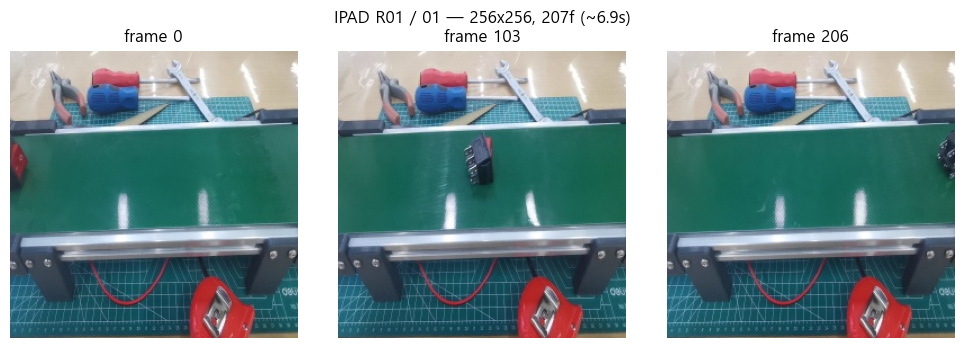

해상도 256x256, 207 frames, ~6.9s @ 30.0fps


In [4]:
root, clip = resolve_ipad_session()
preview = read_frames_bgr(clip, [0, clip.num_frames // 2, clip.num_frames - 1])
h, w = preview[0].shape[:2]
duration = clip.num_frames / FPS_ASSUMED

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))
for ax, idx, img in zip(axes, [0, clip.num_frames // 2, clip.num_frames - 1], preview):
    ax.imshow(bgr_to_rgb(img))
    ax.set_title(f"frame {idx}")
    ax.axis("off")
fig.suptitle(
    f"IPAD {clip.device} / {clip.clip_id} — {w}x{h}, {clip.num_frames}f (~{duration:.1f}s)",
    fontsize=12,
)
plt.tight_layout()
fig.savefig(FIG_DIR / "01_ipad_preview.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"해상도 {w}x{h}, {clip.num_frames} frames, ~{duration:.1f}s @ {FPS_ASSUMED}fps")


## 1.5 디코딩 병목 현상 이해 
**Video 처리 최적화**는 "왜 비디오 처리가 전체 AI 파이프라인의 병목인가"를 설명합니다.

### 병목 3요소

| 병목 | 원인 | 실습 코드에서의 대응 |
|------|------|---------------------|
| **CPU-Bound Decoding** | 프레임 디코딩이 CPU에서 순차 수행 | 배치 인덱스 로딩(`get_batch` 패턴) |
| **I/O Overhead** | 프레임 데이터가 이미지 대비 대용량 | 필요한 인덱스만 읽기 |
| **Inference Gap** | 모델은 빠른데 데이터 공급이 느림 | 샘플링 + 배치 전처리 파이프라인 |

### 라이브러리 비교 (교재)

| 라이브러리 | 주 사용 맥락 | GPU 디코딩 | 임의 프레임 접근 | 적합 용도 |
|-----------|-------------|-----------|----------------|----------|
| **OpenCV** | 범용 Vision | 제한적 | 느림(프레임 단위 seek) | 일반 전처리 |
| **Decord** | 딥러닝 학습 | 높음(NVDEC) | 매우 빠름 | 대규모 학습 |
| **PyTorchVideo** | PyTorch 생태계 | 통합형 | 최적화됨 | PyTorch 파이프라인 |

IPAD는 jpg 시퀀스이므로, 아래 벤치마크는 **OpenCV 방식의 3가지 읽기 패턴**을 비교하고,
mp4로 변환한 뒤 **Decord 배치 로딩(선택)** 도 시연합니다.


[Decord] 미설치 — pip install decord 후 재실행
저장: output_sampling\figures\01b_library_matrix.png


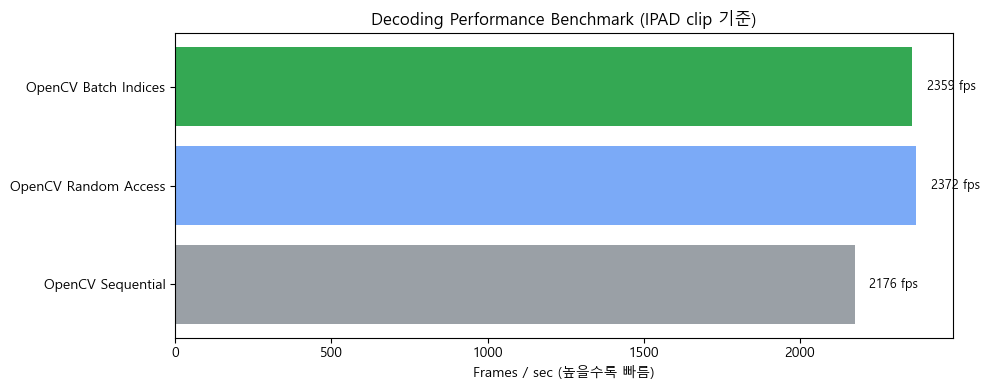

저장: output_sampling\figures\01c_decode_benchmark.png
  OpenCV Sequential        | 207 frames | 0.095s |    2176 fps
  OpenCV Random Access     |  32 frames | 0.013s |    2372 fps
  OpenCV Batch Indices     |  32 frames | 0.014s |    2359 fps


In [5]:
import time
from dataclasses import dataclass

BENCHMARK_DIR = OUTPUT_DIR / "benchmark"
BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)


@dataclass
class DecodeBenchmark:
    """디코딩 방식별 성능 측정 결과."""
    name: str
    elapsed_sec: float
    num_frames: int
    fps: float


def benchmark_opencv_sequential(clip: IpadClip) -> DecodeBenchmark:
    """프레임 0부터 순차적으로 전부 읽기 (가장 단순, CPU-bound)."""
    t0 = time.perf_counter()
    frames = read_frames_bgr(clip)
    elapsed = time.perf_counter() - t0
    return DecodeBenchmark("OpenCV Sequential", elapsed, len(frames), len(frames) / max(elapsed, 1e-6))


def benchmark_opencv_random(clip: IpadClip, indices: np.ndarray) -> DecodeBenchmark:
    """임의 인덱스를 하나씩 읽기 (seek/random access 비용 확인)."""
    t0 = time.perf_counter()
    # 매 인덱스마다 imread 1회 -> I/O + 디코딩 반복
    _ = [cv2.imread(str(clip.frame_paths[int(i)])) for i in indices]
    elapsed = time.perf_counter() - t0
    return DecodeBenchmark("OpenCV Random Access", elapsed, len(indices), len(indices) / max(elapsed, 1e-6))


def benchmark_opencv_batch(clip: IpadClip, indices: np.ndarray) -> DecodeBenchmark:
    """선택 인덱스만 배치로 읽기 (Decord get_batch와 같은 사용 패턴)."""
    t0 = time.perf_counter()
    _ = read_frames_bgr(clip, indices)
    elapsed = time.perf_counter() - t0
    return DecodeBenchmark("OpenCV Batch Indices", elapsed, len(indices), len(indices) / max(elapsed, 1e-6))


def clip_to_mp4(clip: IpadClip, out_path: Path, fps: float = FPS_ASSUMED) -> Path:
    """IPAD jpg 시퀀스를 mp4로 변환 (Decord 실습용)."""
    first = cv2.imread(str(clip.frame_paths[0]))
    h, w = first.shape[:2]
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(out_path), fourcc, fps, (w, h))
    for p in clip.frame_paths:
        img = cv2.imread(str(p))
        if img is not None:
            writer.write(img)
    writer.release()
    return out_path


def benchmark_decord_batch(mp4_path: Path, indices: np.ndarray) -> DecodeBenchmark | None:
    """Decord GPU/CPU 배치 디코딩 (설치된 경우만)."""
    try:
        import decord
        from decord import VideoReader, cpu, gpu
    except ImportError:
        print("[Decord] 미설치 — pip install decord 후 재실행")
        return None

    # GPU NVDEC 사용 가능하면 gpu(0), 아니면 cpu()
    try:
        ctx = gpu(0)
        mode = "Decord GPU Batch"
    except Exception:
        ctx = cpu(0)
        mode = "Decord CPU Batch"

    vr = VideoReader(str(mp4_path), ctx=ctx)
    t0 = time.perf_counter()
    _ = vr.get_batch(indices.tolist()).asnumpy()
    elapsed = time.perf_counter() - t0
    return DecodeBenchmark(mode, elapsed, len(indices), len(indices) / max(elapsed, 1e-6))


def plot_library_matrix(save_path: Path) -> None:
    """교재의 Library Comparison Matrix를 표 형태로 시각화."""
    rows = [
        ("OpenCV", "Generic Vision", "Limited", "Slow", "General Tasks"),
        ("Decord", "Deep Learning", "High (NVDEC)", "Very Fast", "Heavy Training"),
        ("PyTorchVideo", "PyTorch Ecosystem", "Integration", "Optimized", "PyTorch Pipelines"),
    ]
    fig, ax = plt.subplots(figsize=(11, 2.8))
    ax.axis("off")
    table = ax.table(
        cellText=rows,
        colLabels=["Library", "Primary Context", "GPU Decoding", "Random Access", "Use Case"],
        loc="center",
        cellLoc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 1.6)
    ax.set_title("Library Comparison Matrix (교재 8-2)", fontsize=12, pad=12)
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    print(f"저장: {save_path}")


def plot_decode_benchmark(results: list[DecodeBenchmark], save_path: Path) -> None:
    """디코딩 방식별 FPS 막대그래프 (교재 벤치마크 형식)."""
    names = [r.name for r in results]
    fps_vals = [r.fps for r in results]
    colors = ["#9aa0a6", "#7baaf7", "#34a853", "#00e5ff"]

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(names, fps_vals, color=colors[: len(names)])
    ax.set_xlabel("Frames / sec (높을수록 빠름)")
    ax.set_title("Decoding Performance Benchmark (IPAD clip 기준)")
    for bar, val in zip(bars, fps_vals):
        ax.text(bar.get_width() + max(fps_vals) * 0.02, bar.get_y() + bar.get_height() / 2,
                f"{val:.0f} fps", va="center", fontsize=9)
    plt.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"저장: {save_path}")


# ── 디코딩 병목 벤치마크 실행 ──
bench_indices = np.linspace(0, clip.num_frames - 1, 32, dtype=int)
bench_results = [
    benchmark_opencv_sequential(clip),
    benchmark_opencv_random(clip, bench_indices),
    benchmark_opencv_batch(clip, bench_indices),
]

mp4_path = BENCHMARK_DIR / f"{clip.device}_{clip.clip_id}.mp4"
if not mp4_path.exists():
    print(f"[mp4] IPAD -> mp4 변환: {mp4_path}")
    clip_to_mp4(clip, mp4_path)

decord_result = benchmark_decord_batch(mp4_path, bench_indices)
if decord_result is not None:
    bench_results.append(decord_result)

plot_library_matrix(FIG_DIR / "01b_library_matrix.png")
plot_decode_benchmark(bench_results, FIG_DIR / "01c_decode_benchmark.png")

for r in bench_results:
    print(f"  {r.name:24s} | {r.num_frames:3d} frames | {r.elapsed_sec:.3f}s | {r.fps:7.0f} fps")


## 2. 프레임 샘플링 자동화

**Frame Sampling Strategies**를 IPAD 산업 데이터에 맞게 확장합니다.

###  3대 전략

| 전략 | 설명 | 코드 |
|------|----------|------|
| **Uniform** | 전체 구간 균등 추출, Global 맥락 | `sample_uniform` |
| **Consecutive** | 특정 시점 연속 프레임, Action 분석 | `sample_consecutive` |
| **Strided** | stride 간격 추출, 연산량·시간 범위 균형 | `sample_strided` |

### 산업 데이터 확장 전략

| 전략 | 핵심 아이디어 | 적합 용도 |
|------|---------------|----------|
| `motion_topk` | Motion Energy 상위 구간 | DETR/이상 탐지 |
| `cycle_aware` | 주기 T 기반 사이클 샘플링 | 반복 공정 설비 |
| `fps` | target FPS 다운샘플 | 스트림 시뮬레이션 |


In [6]:
class SamplingStrategy(str, Enum):
    # 균등 간격 샘플링: 전체 시간축 요약에 유리 (교재 Uniform)
    UNIFORM = "uniform"
    # 특정 시점부터 연속 프레임: 짧은 action/motion 분석 (교재 Consecutive)
    CONSECUTIVE = "consecutive"
    # 일정 stride 간격 샘플링: 연산량 조절 + temporal span 확보 (교재 Strided)
    STRIDED = "strided"
    # 움직임이 큰 프레임 우선 샘플링: 이벤트/이상 포착에 유리
    MOTION_TOPK = "motion_topk"
    # 추정 주기 기반 샘플링: 반복 공정(산업 데이터)에 유리
    CYCLE_AWARE = "cycle_aware"
    # 가상 FPS로 다운샘플링: 스트림 처리 시뮬레이션에 유리
    FPS = "fps"


@dataclass
class SamplingResult:
    # 어떤 전략으로 뽑았는지
    strategy: SamplingStrategy
    # 선택된 프레임 인덱스 목록
    indices: np.ndarray
    # 필요 시 함께 반환되는 모션 시계열
    motion_energy: np.ndarray | None = None
    # cycle_aware에서 쓰는 추정 주기
    period: int | None = None
    # 확장 메타정보 (target_fps 등)
    meta: dict = field(default_factory=dict)


def compute_motion_energy(frames: list[np.ndarray]) -> np.ndarray:
    """연속 프레임 그레이 차분 평균 — 길이 len(frames)-1."""
    energy = []
    for i in range(len(frames) - 1):
        g0 = cv2.cvtColor(frames[i], cv2.COLOR_BGR2GRAY)
        g1 = cv2.cvtColor(frames[i + 1], cv2.COLOR_BGR2GRAY)
        # |F(t+1)-F(t)|의 평균값: 프레임 간 변화량을 1개 scalar로 요약
        energy.append(float(np.mean(cv2.absdiff(g0, g1))))
    return np.asarray(energy, dtype=np.float64)


def estimate_period_frames(motion: np.ndarray, min_period: int = 8) -> int:
    """Autocorrelation으로 1사이클 프레임 수 추정 (02 노트북과 동일 아이디어)."""
    # 평균 제거: DC 성분을 줄여 주기 peak가 더 잘 보이게 함
    x = motion - motion.mean()
    if len(x) < min_period * 2:
        # 데이터가 너무 짧으면 보수적으로 fallback
        return max(min_period, len(x) // 4)

    # full autocorrelation 후 양의 지연(lag) 구간만 사용
    ac = sp_signal.correlate(x, x, mode="full")
    ac = ac[len(ac) // 2 :]
    ac[0] = 0  # lag=0 자기상관은 항상 최대이므로 제거

    # 지나치게 큰 lag는 실용성이 떨어져 상한(120프레임) 제한
    search = ac[min_period : min(len(ac) // 2, 120)]
    if len(search) == 0:
        return min_period
    return int(np.argmax(search) + min_period)


def sample_uniform(total: int, num: int) -> np.ndarray:
    """시작~끝 구간을 균등 분할해 num개 선택."""
    return np.linspace(0, max(total - 1, 0), num=num, dtype=int)


def sample_motion_topk(motion: np.ndarray, num: int) -> np.ndarray:
    """모션 상위 구간 + 양끝 프레임을 함께 유지하는 전략."""
    total = len(motion) + 1
    num = min(num, total)
    if num <= 2:
        return sample_uniform(total, num)

    # 양끝(시작/끝)을 남겨 전체 문맥을 보존
    inner_k = num - 2
    peak_idx = np.argpartition(motion, -inner_k)[-inner_k:]
    # motion[i]는 i->i+1 변화량이므로 대표 프레임을 i+1로 대응
    peak_idx = np.sort(peak_idx + 1)
    return np.unique(np.concatenate([[0], peak_idx, [total - 1]]))


def sample_cycle_aware(total: int, period: int, num: int) -> np.ndarray:
    """추정 주기 기준으로 사이클별 균등 샘플링."""
    num_cycles = max(1, total // max(period, 1))
    per_cycle = max(1, num // num_cycles)
    picks = []
    for c in range(num_cycles):
        start = c * period
        end = min(start + period, total)
        if start >= total:
            break
        local = np.linspace(start, end - 1, num=per_cycle, dtype=int)
        picks.extend(local.tolist())

    # 중복 제거 후 부족하면 uniform으로 보강
    indices = np.unique(picks)
    if len(indices) < num:
        extra = sample_uniform(total, num)
        indices = np.unique(np.concatenate([indices, extra]))[:num]
    return indices[:num]




def sample_consecutive(total: int, num: int, start_index: int = 0) -> np.ndarray:
    """특정 시점부터 연속 num개 프레임을 추출 (교재 Consecutive Sampling)."""
    start = int(np.clip(start_index, 0, max(total - 1, 0)))
    end = min(start + num, total)
    return np.arange(start, end, dtype=int)


def sample_strided(total: int, num: int, stride: int = 5, start_index: int = 0) -> np.ndarray:
    """stride 간격으로 프레임 추출 (교재 Strided Sampling)."""
    start = int(np.clip(start_index, 0, max(total - 1, 0)))
    idx = np.arange(start, total, max(1, stride), dtype=int)
    if len(idx) > num:
        # num개를 유지하면서 temporal span을 넓게 가져가기 위해 재간격화
        pick = np.linspace(0, len(idx) - 1, num=num, dtype=int)
        idx = idx[pick]
    return idx

def sample_fps(total: int, fps_source: float, target_fps: float) -> np.ndarray:
    """원본 fps를 target fps로 다운샘플링한 인덱스 생성."""
    step = max(1, int(round(fps_source / max(target_fps, 0.1))))
    return np.arange(0, total, step, dtype=int)


class FrameSampler:
    """IPAD 클립용 프레임 샘플링 자동화 클래스."""

    def __init__(self, clip: IpadClip, fps: float = FPS_ASSUMED):
        self.clip = clip
        self.fps = fps
        # lazy cache: motion/cycle 계산은 처음 1회만 수행
        self._frames: list[np.ndarray] | None = None
        self._motion: np.ndarray | None = None
        self._period: int | None = None

    def _ensure_motion(self) -> tuple[list[np.ndarray], np.ndarray]:
        if self._frames is None:
            self._frames = read_frames_bgr(self.clip)
            self._motion = compute_motion_energy(self._frames)
            self._period = estimate_period_frames(self._motion)
        return self._frames, self._motion  # type: ignore

    @property
    def period(self) -> int:
        self._ensure_motion()
        return self._period  # type: ignore

    def sample(
        self,
        num_frames: int,
        strategy: SamplingStrategy = SamplingStrategy.UNIFORM,
        *,
        target_fps: float = 2.0,
        start_index: int = 0,
        stride: int = 5,
    ) -> SamplingResult:
        """전략별 샘플링 엔트리 포인트."""
        n = self.clip.num_frames

        if strategy == SamplingStrategy.UNIFORM:
            idx = sample_uniform(n, num_frames)
            return SamplingResult(strategy, idx)

        if strategy == SamplingStrategy.CONSECUTIVE:
            idx = sample_consecutive(n, num_frames, start_index=start_index)
            return SamplingResult(strategy, idx, meta={"start_index": start_index})

        if strategy == SamplingStrategy.STRIDED:
            idx = sample_strided(n, num_frames, stride=stride, start_index=start_index)
            return SamplingResult(strategy, idx, meta={"stride": stride, "start_index": start_index})

        if strategy == SamplingStrategy.FPS:
            idx = sample_fps(n, self.fps, target_fps)
            return SamplingResult(strategy, idx, meta={"target_fps": target_fps})

        # 아래 전략들은 motion/cycle 정보가 필요
        _, motion = self._ensure_motion()

        if strategy == SamplingStrategy.MOTION_TOPK:
            idx = sample_motion_topk(motion, num_frames)
            return SamplingResult(strategy, idx, motion_energy=motion)

        if strategy == SamplingStrategy.CYCLE_AWARE:
            idx = sample_cycle_aware(n, self.period, num_frames)
            return SamplingResult(
                strategy,
                idx,
                motion_energy=motion,
                period=self.period,
                meta={"period_frames": self.period},
            )

        raise ValueError(strategy)

    def preset(self, model: str) -> SamplingResult:
        """모델 이름에 맞는 샘플링 프리셋."""
        key = model.lower()
        if key in ("swin", "swin-t", "classifier"):
            return self.sample(SWIN_NUM_FRAMES, SamplingStrategy.CYCLE_AWARE)
        if key in ("detr", "detector"):
            return self.sample(DETR_NUM_FRAMES, SamplingStrategy.MOTION_TOPK)
        if key == "preview":
            return self.sample(PREVIEW_NUM_FRAMES, SamplingStrategy.UNIFORM)
        return self.sample(8, SamplingStrategy.UNIFORM)


def export_sampled_clip(
    clip: IpadClip,
    result: SamplingResult,
    out_dir: Path,
    *,
    tag: str = "export",
) -> Path:
    """샘플링된 프레임을 PNG로 저장하고 manifest JSON을 기록."""
    out = out_dir / f"{clip.device}_{clip.split}_{clip.clip_id}_{tag}_{result.strategy.value}"
    out.mkdir(parents=True, exist_ok=True)

    manifest = {
        "device": clip.device,
        "split": clip.split,
        "clip_id": clip.clip_id,
        "strategy": result.strategy.value,
        "indices": result.indices.tolist(),
        "num_frames": int(len(result.indices)),
        "period": result.period,
        "meta": result.meta,
        "files": [],
    }

    for rank, idx in enumerate(result.indices):
        src = clip.frame_paths[int(idx)]
        dst = out / f"{rank:03d}_f{int(idx):04d}.png"
        img = cv2.imread(str(src))
        cv2.imwrite(str(dst), img)
        manifest["files"].append({"rank": rank, "frame_index": int(idx), "path": dst.name})

    with open(out / "manifest.json", "w", encoding="utf-8") as f:
        json.dump(manifest, f, ensure_ascii=False, indent=2)

    print(f"[export] {len(result.indices)} frames -> {out.resolve()}")
    return out


# 실습용: 전체 모션과 주기를 먼저 계산해 확인
sampler = FrameSampler(clip)
motion = compute_motion_energy(read_frames_bgr(clip))
period_est = estimate_period_frames(motion)
print(f"추정 주기: {period_est} frames (~{period_est / FPS_ASSUMED:.2f}s)")


추정 주기: 30 frames (~1.00s)


저장: output_sampling\figures\02_sampling_strategies.png


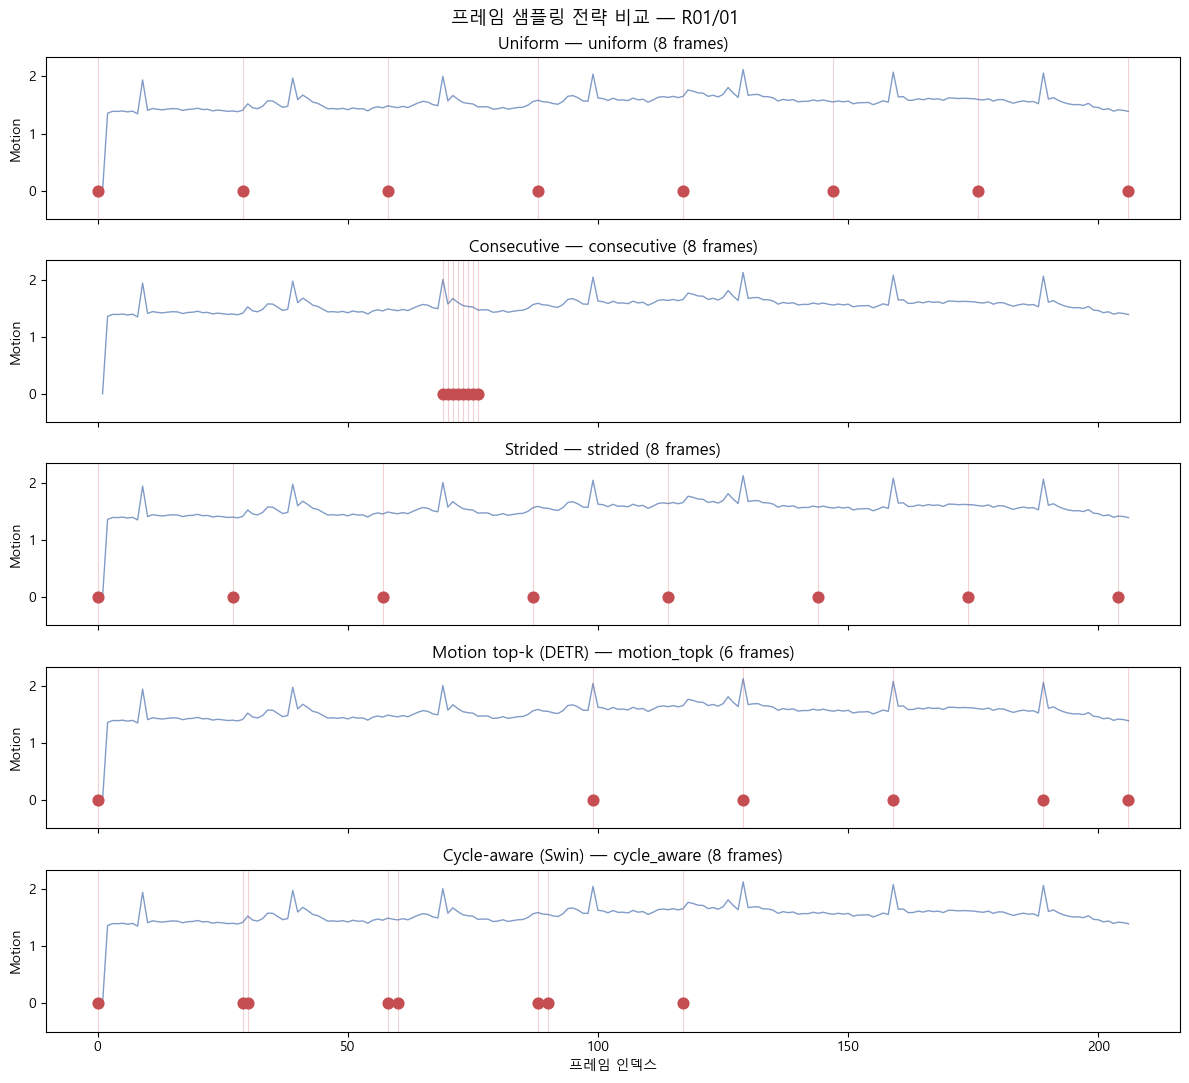

[export] 8 frames -> C:\MyCursorLab\08_Video AI 처리 및 분석\output_sampling\sampled_frames\R01_training_01_uniform_uniform
[export] 8 frames -> C:\MyCursorLab\08_Video AI 처리 및 분석\output_sampling\sampled_frames\R01_training_01_consecutive_consecutive
[export] 8 frames -> C:\MyCursorLab\08_Video AI 처리 및 분석\output_sampling\sampled_frames\R01_training_01_strided_strided
[export] 6 frames -> C:\MyCursorLab\08_Video AI 처리 및 분석\output_sampling\sampled_frames\R01_training_01_motion_motion_topk
[export] 8 frames -> C:\MyCursorLab\08_Video AI 처리 및 분석\output_sampling\sampled_frames\R01_training_01_cycle-aware_cycle_aware
통합 manifest: C:\MyCursorLab\08_Video AI 처리 및 분석\output_sampling\sampling_manifest.json


In [7]:
def plot_sampling_timeline(
    clip: IpadClip,
    results: dict[str, SamplingResult],
    motion: np.ndarray | None = None,
    *,
    save_path: Path | None = None,
) -> None:
    """여러 샘플링 전략을 Motion Energy 타임라인 위에 표시."""
    nrows = len(results)
    fig, axes = plt.subplots(nrows, 1, figsize=(12, 2.2 * nrows), sharex=True)
    if nrows == 1:
        axes = [axes]

    for ax, (name, res) in zip(axes, results.items()):
        if motion is not None and len(motion) == clip.num_frames - 1:
            ax.plot(np.arange(1, clip.num_frames), motion, color="#4C72B0", lw=1, alpha=0.7)
            ax.set_ylabel("Motion")
        ax.scatter(res.indices, np.zeros_like(res.indices), c="#C44E52", s=60, zorder=3)
        for idx in res.indices:
            ax.axvline(idx, color="#C44E52", alpha=0.25, lw=0.8)
        y_max = max(motion.max() * 1.1, 1) if motion is not None else 1
        ax.set_ylim(-0.5, y_max)
        ax.set_title(f"{name} — {res.strategy.value} ({len(res.indices)} frames)")

    axes[-1].set_xlabel("프레임 인덱스")
    fig.suptitle(f"프레임 샘플링 전략 비교 — {clip.device}/{clip.clip_id}", fontsize=13)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"저장: {save_path}")
    plt.show()


strategies = {
    "Uniform": sampler.sample(SWIN_NUM_FRAMES, SamplingStrategy.UNIFORM),
    "Consecutive": sampler.sample(8, SamplingStrategy.CONSECUTIVE, start_index=clip.num_frames // 3),
    "Strided": sampler.sample(8, SamplingStrategy.STRIDED, stride=max(1, clip.num_frames // 64)),
    "Motion top-k (DETR)": sampler.sample(DETR_NUM_FRAMES, SamplingStrategy.MOTION_TOPK),
    "Cycle-aware (Swin)": sampler.sample(SWIN_NUM_FRAMES, SamplingStrategy.CYCLE_AWARE),
}
motion = compute_motion_energy(read_frames_bgr(clip))
plot_sampling_timeline(clip, strategies, motion, save_path=FIG_DIR / "02_sampling_strategies.png")

exports = {}
for label, res in strategies.items():
    tag = label.split()[0].lower().replace("(", "").replace(")", "")
    exports[label] = str(export_sampled_clip(clip, res, SAMPLE_DIR, tag=tag))

manifest_all = {
    "clip": {"device": clip.device, "split": clip.split, "clip_id": clip.clip_id},
    "period_estimate": sampler.period,
    "exports": exports,
    "presets": {
        "swin": sampler.preset("swin").indices.tolist(),
        "detr": sampler.preset("detr").indices.tolist(),
    },
}
with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest_all, f, ensure_ascii=False, indent=2)
print(f"통합 manifest: {MANIFEST_PATH.resolve()}")


## 2.5 GPU 배치 로딩 실습

권장 워크플로는 다음 4단계입니다.

1. 비디오를 GPU 컨텍스트로 로드
2. 샘플링 인덱스를 배치로 구성
3. `get_batch(indices)`로 한 번에 디코딩
4. 딥러닝 텐서(Torch)로 바로 변환

IPAD jpg 시퀀스에서도 동일 패턴을 적용할 수 있도록 `IpadBatchReader`를 구현합니다.
Decord가 설치되어 있으면 mp4 경로에서 GPU 배치 로딩도 추가로 시연합니다.


[GPU Batch Pipeline]
  swin_batch_shape: [8, 256, 256, 3]
  swin_tensor_shape: [8, 3, 256, 256]
  swin_device: cuda:0
  detr_indices: [0, 99, 129, 159, 189, 206]
  decord_note: skip: No module named 'decord'


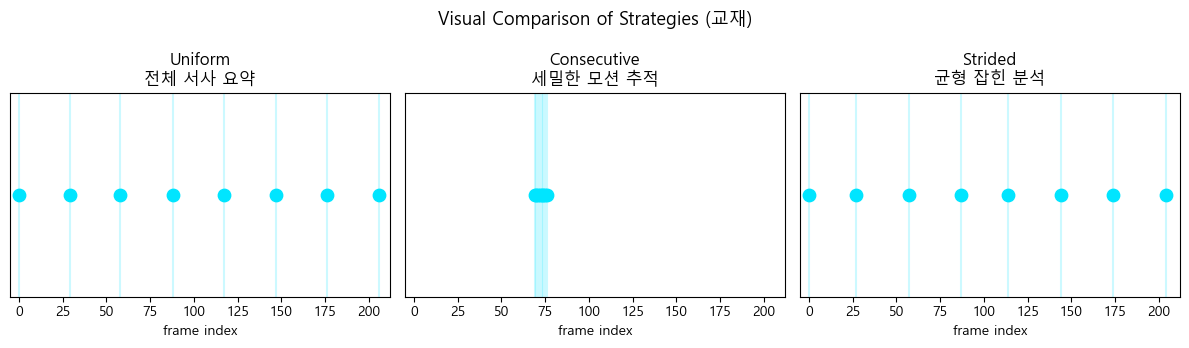

저장: output_sampling\figures\02b_textbook_strategy_cards.png


In [8]:
class IpadBatchReader:
    """Decord VideoReader와 유사한 get_batch API를 IPAD jpg 시퀀스에 제공."""

    def __init__(self, clip: IpadClip):
        self.clip = clip
        self.num_frames = clip.num_frames

    def get_batch(self, indices: list[int] | np.ndarray) -> np.ndarray:
        """선택 인덱스 프레임을 (N,H,W,C) RGB uint8 배열로 반환."""
        idx = [int(i) for i in indices]
        rgb = [bgr_to_rgb(cv2.imread(str(self.clip.frame_paths[i]))) for i in idx]
        return np.stack(rgb, axis=0)

    def get_batch_tensor(self, indices: list[int] | np.ndarray, device: torch.device = DEVICE) -> torch.Tensor:
        """배치 프레임을 Swin/DETR 입력용 float tensor로 변환."""
        batch = self.get_batch(indices)
        # (N,H,W,C) -> (N,C,H,W), [0,1] 정규화
        tensor = torch.from_numpy(batch).permute(0, 3, 1, 2).float() / 255.0
        return tensor.to(device)


def demo_gpu_batch_pipeline(clip: IpadClip, sampler: FrameSampler) -> dict:
    """교재 4단계 워크플로를 IPAD + Torch로 재현."""
    reader = IpadBatchReader(clip)
    swin_idx = sampler.preset("swin").indices
    detr_idx = sampler.preset("detr").indices

    # 1) 인덱스 배치 구성
    # 2) get_batch로 한 번에 로드
    swin_batch = reader.get_batch(swin_idx)
    swin_tensor = reader.get_batch_tensor(swin_idx)

    report = {
        "swin_batch_shape": list(swin_batch.shape),
        "swin_tensor_shape": list(swin_tensor.shape),
        "swin_device": str(swin_tensor.device),
        "detr_indices": detr_idx.tolist(),
    }

    # Decord가 있으면 mp4에서도 동일 인덱스 배치 로딩 비교
    mp4_path = BENCHMARK_DIR / f"{clip.device}_{clip.clip_id}.mp4"
    try:
        import decord
        from decord import VideoReader, cpu, gpu
        decord.bridge.set_bridge("torch")
        ctx = gpu(0)
        try:
            vr = VideoReader(str(mp4_path), ctx=ctx)
        except Exception:
            ctx = cpu(0)
            vr = VideoReader(str(mp4_path), ctx=ctx)
        decord_batch = vr.get_batch(swin_idx.tolist())
        report["decord_batch_shape"] = list(decord_batch.shape)
        report["decord_ctx"] = str(ctx)
    except Exception as exc:
        report["decord_note"] = f"skip: {exc}"

    return report


batch_report = demo_gpu_batch_pipeline(clip, sampler)
print("[GPU Batch Pipeline]")
for k, v in batch_report.items():
    print(f"  {k}: {v}")

# 교재 전략 3종 시각 비교 카드 (Uniform / Consecutive / Strided)
textbook_strategies = {
    "Uniform": sampler.sample(8, SamplingStrategy.UNIFORM),
    "Consecutive": sampler.sample(8, SamplingStrategy.CONSECUTIVE, start_index=clip.num_frames // 3),
    "Strided": sampler.sample(8, SamplingStrategy.STRIDED, stride=max(1, clip.num_frames // 64)),
}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
subtitles = {
    "Uniform": "전체 서사 요약",
    "Consecutive": "세밀한 모션 추적",
    "Strided": "균형 잡힌 분석",
}
for ax, (name, res) in zip(axes, textbook_strategies.items()):
    ax.scatter(res.indices, np.ones_like(res.indices), s=80, c="#00e5ff")
    for x in res.indices:
        ax.axvline(x, color="#00e5ff", alpha=0.2)
    ax.set_xlim(-5, clip.num_frames + 5)
    ax.set_ylim(0.5, 1.5)
    ax.set_yticks([])
    ax.set_xlabel("frame index")
    ax.set_title(f"{name}\n{subtitles[name]}")
fig.suptitle("Visual Comparison of Strategies (교재)", fontsize=13)
plt.tight_layout()
fig.savefig(FIG_DIR / "02b_textbook_strategy_cards.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장:", FIG_DIR / "02b_textbook_strategy_cards.png")


## 3. Swin Transformer — 프레임별 Spatial 분류

### Swin을 왜 쓰나?
- 일반 ViT는 전체 토큰 attention이라 비용이 큽니다.
- Swin은 **작은 윈도우 단위 attention + 계층 구조**로 계산량을 줄이면서 지역 정보를 잘 잡습니다.
- 본 실습에서는 비디오 전체가 아니라 샘플링된 프레임 집합에 적용해 Spatial 표현 변화를 확인합니다.

### 추론 흐름 (쉽게)
1. 샘플링된 RGB 프레임 리스트 준비
2. `AutoImageProcessor`가 크기 조정/정규화 수행
3. `AutoModelForImageClassification`이 logits 출력
4. softmax 후 Top-k 라벨 추출
5. 프레임 간 logits 코사인 유사도로 feature 일관성 확인

### 이 결과를 어떻게 해석하나?
- Top-1 라벨 이름 자체는 산업 데이터에서 정확하지 않을 수 있습니다.
- 대신 "프레임 간 유사도가 안정적인지/갑자기 떨어지는지"가 더 중요한 신호입니다.
- 즉, 이 섹션의 목적은 **정확한 클래스 맞추기**보다 **Spatial feature 변화 관찰**입니다.

- 모델: `microsoft/swin-tiny-patch4-window7-224` (ImageNet-1k)
- 입력: Cycle-aware 샘플링 `SWIN_NUM_FRAMES`장
- 출력: Top-5 클래스 + logits cosine similarity heatmap


Loading weights:   0%|          | 0/221 [00:00<?, ?it/s]

  frame   0 -> oscilloscope, scope, cathode-ray oscilloscope, CRO (51.6%)
  frame  29 -> oscilloscope, scope, cathode-ray oscilloscope, CRO (55.6%)
  frame  30 -> oscilloscope, scope, cathode-ray oscilloscope, CRO (57.6%)
  frame  58 -> oscilloscope, scope, cathode-ray oscilloscope, CRO (51.1%)
  frame  60 -> oscilloscope, scope, cathode-ray oscilloscope, CRO (42.9%)
  frame  88 -> oscilloscope, scope, cathode-ray oscilloscope, CRO (34.7%)
  frame  90 -> oscilloscope, scope, cathode-ray oscilloscope, CRO (33.8%)
  frame 117 -> oscilloscope, scope, cathode-ray oscilloscope, CRO (31.8%)
저장: output_sampling\figures\03_swin_classification.png


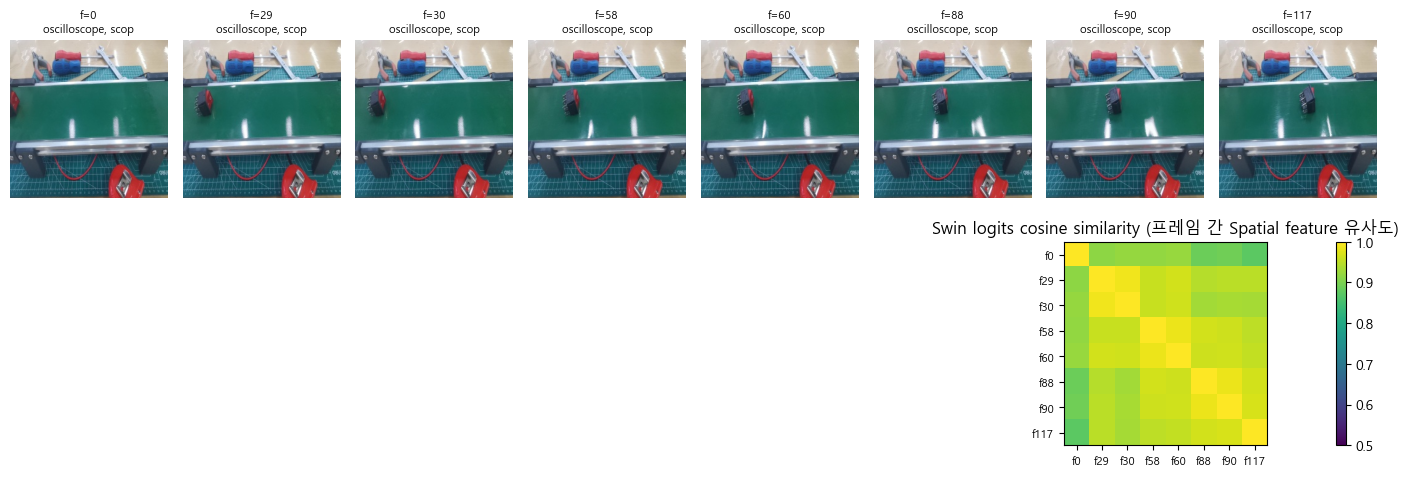

In [9]:
def load_swin_model():
    """Swin 분류 모델과 전처리기를 로드한다."""
    processor = AutoImageProcessor.from_pretrained(SWIN_MODEL_ID)
    model = AutoModelForImageClassification.from_pretrained(SWIN_MODEL_ID)
    model.eval().to(DEVICE)
    return processor, model


@torch.inference_mode()
def swin_classify_frames(
    rgb_frames: list[np.ndarray],
    processor,
    model,
    *,
    top_k: int = 5,
) -> tuple[list[dict], torch.Tensor]:
    """Swin-T로 프레임별 ImageNet 분류 + logits 텐서 반환."""
    # 1) processor가 resize/normalize 등 모델 입력 규격으로 변환
    inputs = processor(images=rgb_frames, return_tensors="pt")
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    # 2) 모델 forward: [N, num_classes] logits 출력
    outputs = model(**inputs)
    logits = outputs.logits.cpu()

    # 3) 확률화 후 프레임별 top-k 라벨 추출
    probs = F.softmax(logits, dim=-1)
    id2label = model.config.id2label
    results = []
    for row in probs:
        vals, idx = torch.topk(row, k=top_k)
        results.append(
            {
                "labels": [id2label[int(i)] for i in idx],
                "scores": [float(v) for v in vals],
            }
        )
    return results, logits


def plot_swin_results(
    rgb_frames: list[np.ndarray],
    indices: np.ndarray,
    preds: list[dict],
    logits: torch.Tensor,
    *,
    save_path: Path | None = None,
) -> None:
    """프레임 격자 + Top-1 라벨 + logits cosine similarity 히트맵."""
    n = len(rgb_frames)

    # logits를 L2 정규화 후 내적하면 cosine similarity 행렬을 얻을 수 있음
    sim = F.normalize(logits.float(), dim=-1)
    cos_mat = (sim @ sim.T).numpy()

    fig = plt.figure(figsize=(14, 5))
    gs = GridSpec(2, max(n, 4), figure=fig, height_ratios=[1.2, 1.0])

    # 상단: 샘플 프레임과 top-1 라벨 표시
    for i, (img, pred) in enumerate(zip(rgb_frames, preds)):
        ax = fig.add_subplot(gs[0, i])
        ax.imshow(img)
        ax.set_title(f"f={indices[i]}\n{pred['labels'][0][:18]}", fontsize=8)
        ax.axis("off")

    # 하단: 프레임 간 feature 유사도 히트맵
    ax_hm = fig.add_subplot(gs[1, :])
    im = ax_hm.imshow(cos_mat, vmin=0.5, vmax=1.0, cmap="viridis")
    ax_hm.set_xticks(range(n))
    ax_hm.set_yticks(range(n))
    ax_hm.set_xticklabels([f"f{indices[i]}" for i in range(n)], fontsize=8)
    ax_hm.set_yticklabels([f"f{indices[i]}" for i in range(n)], fontsize=8)
    ax_hm.set_title("Swin logits cosine similarity (프레임 간 Spatial feature 유사도)")
    fig.colorbar(im, ax=ax_hm, fraction=0.03)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"저장: {save_path}")
    plt.show()


if RUN_SWIN:
    # Swin은 주기 기반 샘플(cycle-aware)을 기본 입력으로 사용
    swin_result = sampler.preset("swin")
    swin_indices = swin_result.indices
    swin_rgb = [bgr_to_rgb(f) for f in read_frames_bgr(clip, swin_indices)]

    swin_proc, swin_model = load_swin_model()
    swin_preds, swin_logits = swin_classify_frames(swin_rgb, swin_proc, swin_model)

    # 프레임별 top-1 예측 로그 출력
    for i, (idx, pred) in enumerate(zip(swin_indices, swin_preds)):
        print(f"  frame {idx:3d} -> {pred['labels'][0]} ({pred['scores'][0]:.1%})")

    plot_swin_results(
        swin_rgb,
        swin_indices,
        swin_preds,
        swin_logits,
        save_path=FIG_DIR / "03_swin_classification.png",
    )
else:
    print("RUN_SWIN=False — Swin 섹션 건너뜀")


## 4. DETR — Transformer 기반 객체 검출

### DETR 핵심 개념
- DETR은 "후보 박스 생성 + NMS" 전통 파이프라인 대신,
  **객체 쿼리(query)** 를 직접 학습해 end-to-end로 박스를 예측합니다.
- 출력은 `box 좌표 + 클래스 + 신뢰도(score)`입니다.

### 본 실습에서의 동작 순서
1. Motion top-k로 변화가 큰 프레임을 우선 선택
2. `DetrImageProcessor`로 전처리 후 모델 입력 생성
3. `DetrForObjectDetection` 추론
4. `post_process_object_detection()`으로 원본 해상도 기준 박스 복원
5. 박스 시각화 + 프레임별 검출 개수 차트 생성

### 왜 오탐이 나올 수 있나?
- 현재 모델은 COCO(일반 사물)로 학습되었습니다.
- 산업 설비 영상에서는 클래스가 맞지 않아 `toothbrush` 같은 라벨이 나올 수 있습니다.
- 따라서 실무에서는 보통 **도메인 라벨로 파인튜닝**이 필요합니다.

- 모델: `facebook/detr-resnet-50` (COCO 91 classes)
- 입력: Motion top-k 샘플링 `DETR_NUM_FRAMES`장
- 출력: bounding box + class + score


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  frame   0 -> 2 boxes | toothbrush(44%), toothbrush(54%)
  frame  99 -> 2 boxes | toothbrush(81%), toothbrush(80%)
  frame 129 -> 2 boxes | toothbrush(39%), toothbrush(62%)
  frame 159 -> 1 boxes | suitcase(38%)
  frame 189 -> 3 boxes | toothbrush(39%), oven(57%), toothbrush(53%)
  frame 206 -> 1 boxes | toothbrush(70%)
저장: output_sampling\figures\04_detr_detection.png


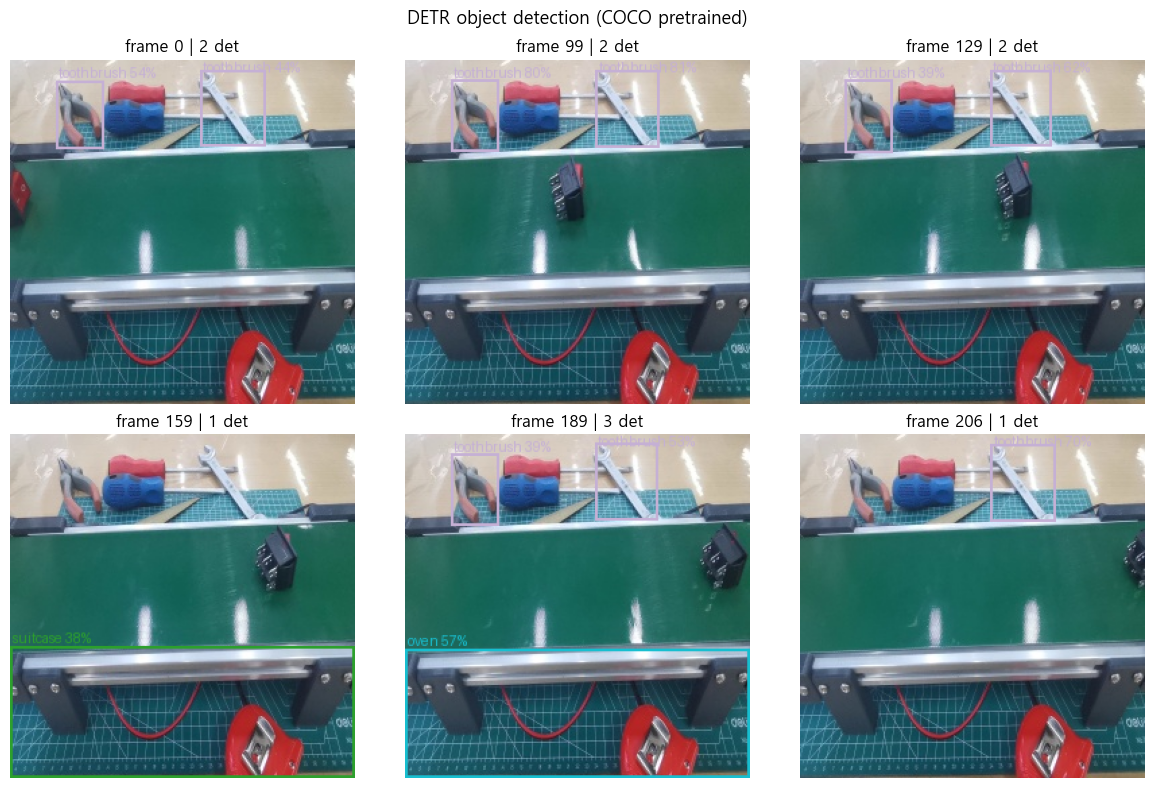

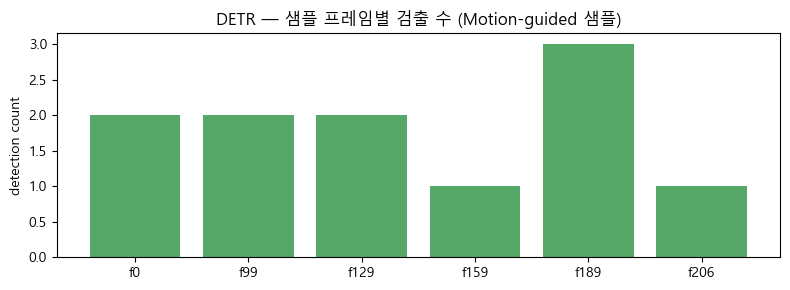

In [10]:
COCO_COLORS = plt.cm.tab20(np.linspace(0, 1, 20))


def load_detr_model():
    """DETR 검출 모델과 전처리기를 로드한다."""
    processor = DetrImageProcessor.from_pretrained(DETR_MODEL_ID)
    model = DetrForObjectDetection.from_pretrained(DETR_MODEL_ID)
    model.eval().to(DEVICE)
    return processor, model


@torch.inference_mode()
def detr_detect_frames(
    pil_images: list[Image.Image],
    processor,
    model,
    *,
    threshold: float = DETR_SCORE_THRESHOLD,
) -> list[dict]:
    """프레임 리스트를 DETR로 추론해 box/label/score를 반환."""
    # 1) PIL 이미지 리스트를 모델 입력 텐서로 변환
    inputs = processor(images=pil_images, return_tensors="pt")
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    # 2) forward 결과는 정규화 좌표 기준이므로 후처리 필요
    outputs = model(**inputs)

    # target_sizes=(H, W): 원본 크기 기준 좌표로 되돌리기 위한 정보
    target_sizes = torch.tensor([[im.size[1], im.size[0]] for im in pil_images])
    processed = processor.post_process_object_detection(
        outputs,
        threshold=threshold,
        target_sizes=target_sizes,
    )

    id2label = model.config.id2label
    results = []
    for det in processed:
        labels = [id2label[int(l)] for l in det["labels"].cpu().tolist()]
        results.append(
            {
                "boxes": det["boxes"].cpu().tolist(),
                "labels": labels,
                "scores": [float(s) for s in det["scores"].cpu().tolist()],
            }
        )
    return results


def draw_detr_boxes(pil_img: Image.Image, det: dict) -> Image.Image:
    """PIL 이미지 위에 DETR bbox·라벨을 그린다."""
    out = pil_img.copy()
    draw = ImageDraw.Draw(out)
    for box, label, score in zip(det["boxes"], det["labels"], det["scores"]):
        x0, y0, x1, y1 = box
        color = tuple(int(c * 255) for c in COCO_COLORS[hash(label) % 20][:3])
        draw.rectangle([x0, y0, x1, y1], outline=color, width=2)
        text = f"{label} {score:.0%}"
        draw.text((x0 + 2, max(0, y0 - 12)), text, fill=color)
    return out


def plot_detr_gallery(
    pil_images: list[Image.Image],
    indices: np.ndarray,
    detections: list[dict],
    *,
    save_path: Path | None = None,
) -> None:
    """검출 박스가 그려진 프레임 갤러리를 생성한다."""
    n = len(pil_images)
    cols = min(n, 3)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.atleast_1d(axes).ravel()

    for i, (im, det, idx) in enumerate(zip(pil_images, detections, indices)):
        vis = draw_detr_boxes(im, det)
        axes[i].imshow(vis)
        axes[i].set_title(f"frame {idx} | {len(det['labels'])} det")
        axes[i].axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle("DETR object detection (COCO pretrained)", fontsize=13)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"저장: {save_path}")
    plt.show()


if RUN_DETR:
    # DETR은 동작 변화가 큰 프레임(motion_topk)을 기본 입력으로 사용
    detr_result = sampler.preset("detr")
    detr_indices = detr_result.indices
    detr_pil = [
        Image.fromarray(bgr_to_rgb(f))
        for f in read_frames_bgr(clip, detr_indices)
    ]

    detr_proc, detr_model = load_detr_model()
    detr_preds = detr_detect_frames(detr_pil, detr_proc, detr_model)

    # 프레임별 검출 요약 로그 (상위 3개 클래스만 표시)
    for idx, det in zip(detr_indices, detr_preds):
        summary = ", ".join(
            f"{label}({score:.0%})"
            for label, score in zip(det["labels"][:3], det["scores"][:3])
        )
        print(f"  frame {idx:3d} -> {len(det['labels'])} boxes | {summary or '-'}")

    plot_detr_gallery(
        detr_pil,
        detr_indices,
        detr_preds,
        save_path=FIG_DIR / "04_detr_detection.png",
    )

    # 프레임별 검출 개수를 막대그래프로 시각화
    counts = [len(d["labels"]) for d in detr_preds]
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.bar(range(len(counts)), counts, color="#55A868")
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels([f"f{idx}" for idx in detr_indices])
    ax.set_ylabel("detection count")
    ax.set_title("DETR — 샘플 프레임별 검출 수 (Motion-guided 샘플)")
    plt.tight_layout()
    fig.savefig(FIG_DIR / "05_detr_counts.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("RUN_DETR=False — DETR 섹션 건너뜀")


## 5. 통합 파이프라인 — 샘플링 → Swin + DETR

`run_spatial_pipeline()`은 실습 코드를 "한 번에 실행 가능한 워크플로"로 묶은 함수입니다.

### 함수가 하는 일
1. 샘플링 프리셋 생성 (Swin용 / DETR용)
2. 샘플 프레임 export + manifest 저장
3. Swin 추론(옵션)
4. DETR 추론(옵션)
5. 결과를 `pipeline_*.json` 리포트로 저장

### 실무에서 이 구조가 좋은 이유
- **재사용성**: 설비/클립만 바꿔서 동일 코드 재사용 가능
- **재현성**: 샘플 인덱스와 결과를 JSON으로 남겨 실험 비교 쉬움
- **확장성**: 이후 anomaly score, rule-based post-process를 단계별로 추가 가능


In [11]:
def run_spatial_pipeline(
    clip: IpadClip,
    *,
    run_swin: bool = RUN_SWIN,
    run_detr: bool = RUN_DETR,
) -> dict:
    """IPAD 클립에 대한 Spatial 분석 자동 파이프라인."""
    smp = FrameSampler(clip)
    report = {"clip": f"{clip.device}/{clip.split}/{clip.clip_id}", "steps": []}

    # 1) 모델별 프리셋 샘플링 인덱스 계산
    swin_res = smp.preset("swin")
    detr_res = smp.preset("detr")
    report["sampling"] = {
        "swin_indices": swin_res.indices.tolist(),
        "detr_indices": detr_res.indices.tolist(),
        "period": smp.period,
    }
    report["steps"].append("sampling")

    # 2) 추론 전에 샘플 프레임 자체를 export (실험 재현/검수용)
    swin_dir = export_sampled_clip(clip, swin_res, SAMPLE_DIR, tag="swin_auto")
    detr_dir = export_sampled_clip(clip, detr_res, SAMPLE_DIR, tag="detr_auto")
    report["export_dirs"] = {"swin": str(swin_dir), "detr": str(detr_dir)}
    report["steps"].append("export")

    # 3) Swin 분류 결과 기록 (프레임별 top-1)
    if run_swin:
        rgb = [bgr_to_rgb(f) for f in read_frames_bgr(clip, swin_res.indices)]
        proc, model = load_swin_model()
        preds, _ = swin_classify_frames(rgb, proc, model, top_k=3)
        report["swin_top1"] = [
            {"frame": int(i), "label": p["labels"][0], "score": p["scores"][0]}
            for i, p in zip(swin_res.indices, preds)
        ]
        report["steps"].append("swin")

    # 4) DETR 검출 결과 기록 (프레임별 검출 개수)
    if run_detr:
        pil = [Image.fromarray(bgr_to_rgb(f)) for f in read_frames_bgr(clip, detr_res.indices)]
        proc, model = load_detr_model()
        dets = detr_detect_frames(pil, proc, model)
        report["detr_counts"] = [
            {"frame": int(i), "num_detections": len(d["labels"])}
            for i, d in zip(detr_res.indices, dets)
        ]
        report["steps"].append("detr")

    # 5) JSON 리포트 저장: 이후 비교/자동화 파이프라인 입력으로 활용
    out_json = OUTPUT_DIR / f"pipeline_{clip.device}_{clip.clip_id}.json"
    with open(out_json, "w", encoding="utf-8") as f:
        json.dump(report, f, ensure_ascii=False, indent=2)
    print(f"파이프라인 리포트: {out_json.resolve()}")
    return report


pipeline_report = run_spatial_pipeline(clip)
print("완료 단계:", " -> ".join(pipeline_report["steps"]))


[export] 8 frames -> C:\MyCursorLab\08_Video AI 처리 및 분석\output_sampling\sampled_frames\R01_training_01_swin_auto_cycle_aware
[export] 6 frames -> C:\MyCursorLab\08_Video AI 처리 및 분석\output_sampling\sampled_frames\R01_training_01_detr_auto_motion_topk


Loading weights:   0%|          | 0/221 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


파이프라인 리포트: C:\MyCursorLab\08_Video AI 처리 및 분석\output_sampling\pipeline_R01_01.json
완료 단계: sampling -> export -> swin -> detr


# 전체 요약

- 디코딩 병목 3요소(CPU/I-O/Inference Gap) 벤치마크
- OpenCV Sequential vs Random vs Batch 비교
- Decord `get_batch` 패턴(선택) + `IpadBatchReader`
- Uniform / Consecutive / Strided 샘플링 전략

## 프레임 샘플링 자동화
- **Uniform**: 전체 서사 요약
- **Consecutive**: 짧은 구간 모션 추적
- **Strided**: 연산량과 temporal span 균형
- **Motion / Cycle-aware**: 산업 IPAD 특화 확장

## Swin Transformer vs DETR

| | Swin-T (2D) | DETR |
|---|-------------|------|
| **과제** | Image Classification | Object Detection |
| **샘플링** | Cycle-aware 8f | Motion top-k 6f |
| **산업 적용** | feature drift 관찰 | 부품 검출(fine-tune 필요) |

## 시리즈 연계
- **01**: Video Transformer / 3D CNN
- **02**: IPAD Temporal Pattern
- **03**: Video 처리 최적화 + Spatial(Swin/DETR)


In [12]:
print("결과 저장:", OUTPUT_DIR.resolve())
print("  figures :", FIG_DIR.resolve())
print("  sampled :", SAMPLE_DIR.resolve())
print("  manifest:", MANIFEST_PATH.resolve())
print(f"\n설비 {clip.device}, 클립 {clip.clip_id}, 주기 ~{sampler.period} frames")
print(
    "다음 단계: testing 클립에 동일 파이프라인 적용 -> train vs test detection/feature 비교"
)


결과 저장: C:\MyCursorLab\08_Video AI 처리 및 분석\output_sampling
  figures : C:\MyCursorLab\08_Video AI 처리 및 분석\output_sampling\figures
  sampled : C:\MyCursorLab\08_Video AI 처리 및 분석\output_sampling\sampled_frames
  manifest: C:\MyCursorLab\08_Video AI 처리 및 분석\output_sampling\sampling_manifest.json

설비 R01, 클립 01, 주기 ~30 frames
다음 단계: testing 클립에 동일 파이프라인 적용 -> train vs test detection/feature 비교
